In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hiopbbpy.problems import Problem
from hiopbbpy.surrogate_modeling import smtKRG 
from hiopbbpy.opt import BnBAlgorithmBase, LCBacquisition

#### Example 

In [2]:
### parameters
n_samples = 10  # number of the initial samples to train GP
theta = 1.e-2  # hyperparameter for GP kernel
nx = 1         # dimension of the problem
c2D=np.array([1.25, 2.5])
c1D=np.array([1.25])
if nx == 1:
    delta = 10.0
    xlimits = np.array([[0.75 - delta/2.,0.75 + delta/2.]])
    c1D = np.array([0.75])
    c = c1D
elif nx == 2:
    c = c2D

class QuadraticShift(Problem):
    """
    f(x) = ||x - c||^2
    - Global minimizer: x* = c
    - Global minimum:   f* = 0
    """
    def __init__(self, ndim=2, xlimits=None, c=None, constraints=[]):
        if xlimits is None:
            xlimits = np.array([[-5.0, 5.0]] * ndim, dtype=float)
        name = "QuadraticShift"
        super().__init__(ndim, xlimits, name=name, constraints=constraints)

        # choose center if not provided
        if c is None:
            c = self.xlimits.mean(axis=1)
        self.c = np.asarray(c, dtype=float)
        assert self.c.shape == (ndim,), "c must be a {0:d}D point".format(ndim)

        # expose known solution for checking later
        # below is true when c is in xlimits
        self.x_star = self.c.copy()
        self.f_star = 0.0 

    def _evaluate(self, x: np.ndarray) -> np.ndarray:
        ne, nx = x.shape
        assert nx == self.ndim
        diff = x - self.c[None, :]
        y = np.sum(diff * diff, axis=1, dtype=float).reshape(ne, 1)
        return y

if nx == 1:
    problem = QuadraticShift(ndim=nx, xlimits=xlimits, c=c)
else:
    problem = QuadraticShift(ndim=nx, c=c)
problem.set_constraints([])  
    
x_train = problem.sample(n_samples)
y_train = problem.evaluate(x_train)

gp_model = smtKRG(theta, problem.xlimits, nx)
gp_model.train(x_train, y_train)

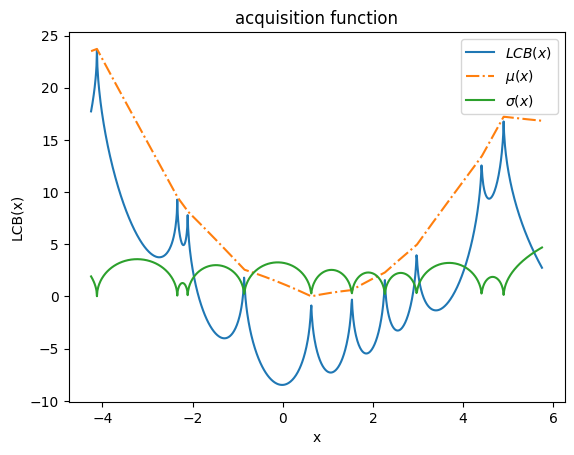

In [3]:
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)
n_plot_pts = 1000
X = np.atleast_2d(np.linspace(l[0], u[0], n_plot_pts)).transpose()

muX = gp_model.mean(X)
sigmaX = np.sqrt(gp_model.variance(X))
beta = 3.0

acqf = LCBacquisition(gp_model, beta=beta)
Y_acqf = acqf.evaluate(X)

plt.plot(X, Y_acqf, label=r'$LCB(x)$')
plt.plot(X, muX, "-.", label=r'$\mu(x)$')
plt.plot(X, sigmaX, label=r'$\sigma(x)$')
plt.xlabel("x")
plt.ylabel("LCB(x)")
plt.legend()
plt.title("acquisition function")
plt.show()

In [4]:
# Build a base "probe" and populate it from the trained SMT model
base = BnBAlgorithmBase(x=x_train, y=y_train)
base.gpsurrogate = gp_model
base.sync_from_smt()              # fills kernel_spec/p, theta, Xc, offsets, beta0/gamma, C, sigma2

# (Optional) ensure we try to compute a nontrivial lower bound for variance
base.BnB_LBmethod = None          # if "IPOPT", sigma2_L will be 0 in your current code
base.beta = beta
# Pick a box to test (use full domain here; swap l/u to any node box you want)
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)

nboxes = 50
box_sizes = (u - l) / float(nboxes)
midpoints = np.zeros((nboxes,))
kLs = np.zeros((nboxes, n_samples))
kUs = np.zeros((nboxes, n_samples))
muLs = np.zeros((nboxes,))
muUs = np.zeros((nboxes,))
s2Ls = np.zeros((nboxes,))
s2Us = np.zeros((nboxes,))
LCB_Ls = np.zeros((nboxes,) * nx)
LCB_Us = np.zeros((nboxes,) * nx)


for i in range(nboxes):
    for j in range(nboxes):
        if nx == 2:
            li = l + np.array([i * box_sizes[0], j * box_sizes[1]])
            ui = l + np.array([(i + 1) * box_sizes[0], (j +1) * box_sizes[1]])
        else:
            if j > 0:
                continue
            li = l + i * box_sizes[0]
            ui = l + (i + 1) * box_sizes[0]
        midpoints[i] = (li[0] + ui[0]) / 2.

        # 1) Bounds from your base class 
        kL, kU         = base.ker_bounds(li, ui)     # per-point kernel bounds vs each trainingsample
        mu_L, mu_U     = base.mu_bounds(kL, kU)      # scalar μ bounds on the box
        s2_L, s2_U     = base.sigma2_bounds(kL, kU,l=li,u=ui)  # scalar σ² bounds on the box
        
        # 2) (Optional) Node LCB/EI bounds using ONLY base.rs_* with your bounds
        LCB_L = acqf.evaluate_meansig2(np.atleast_1d(mu_L), np.atleast_1d(s2_U))[0]
        LCB_U = acqf.evaluate_meansig2(np.atleast_1d(mu_U), np.atleast_1d(s2_L))[0]
        #LCB_L = base.rs_lcb(mu_L, np.sqrt(max(s2_U, 0.0)))     # lower bound on LCB over the box
        #LCB_U = base.rs_lcb(mu_U, np.sqrt(max(s2_L, 0.0)))     # upper bound on LCB over the box
        
        if nx == 1:
            LCB_Ls[i] = LCB_L
            LCB_Us[i] = LCB_U
            midpoints[i] = (li[0] + ui[0]) / 2.
        elif nx == 2:
            LCB_Ls[i][j] = LCB_L
            LCB_Us[i][j] = LCB_U
        
        

        muLs[i] = mu_L
        muUs[i] = mu_U
        s2Ls[i] = s2_L
        s2Us[i] = s2_U
        kLs[i,:] = kL[:]
        kUs[i,:] = kU[:]       
mu = gp_model.mean(midpoints)
s2 = gp_model.variance(midpoints)

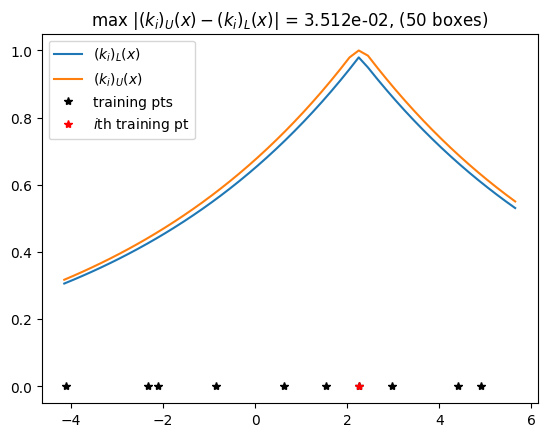

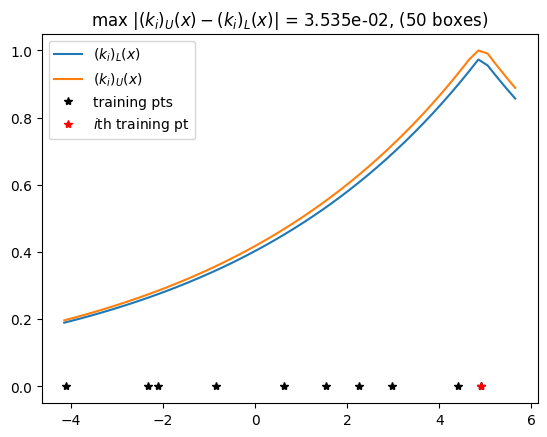

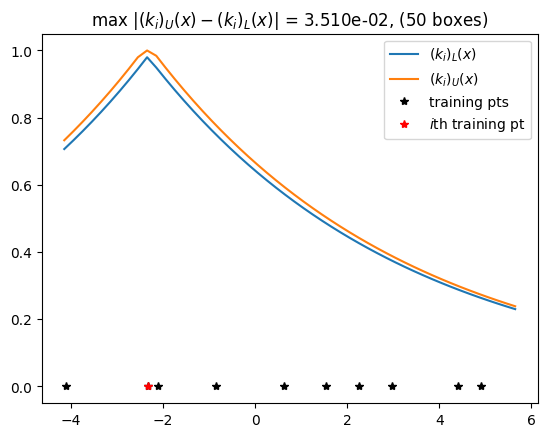

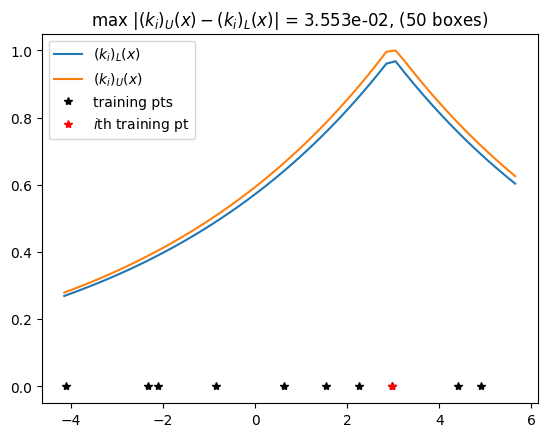

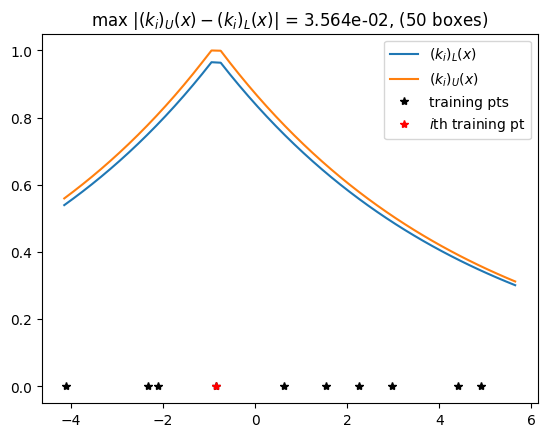

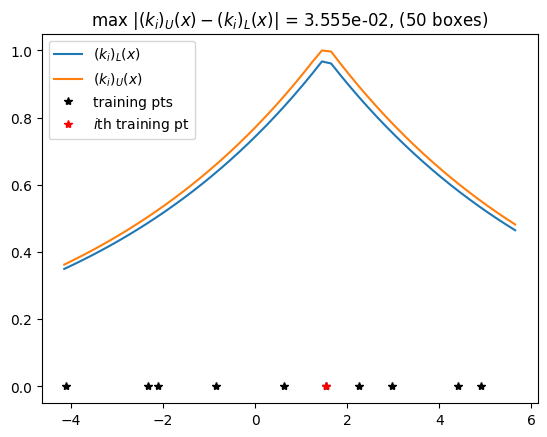

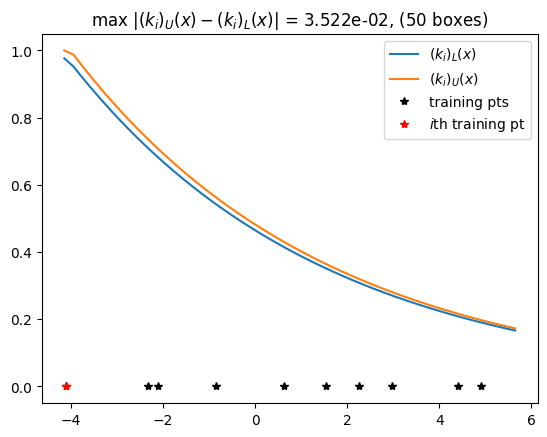

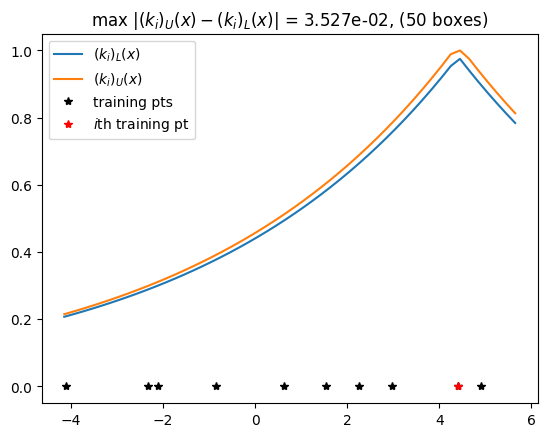

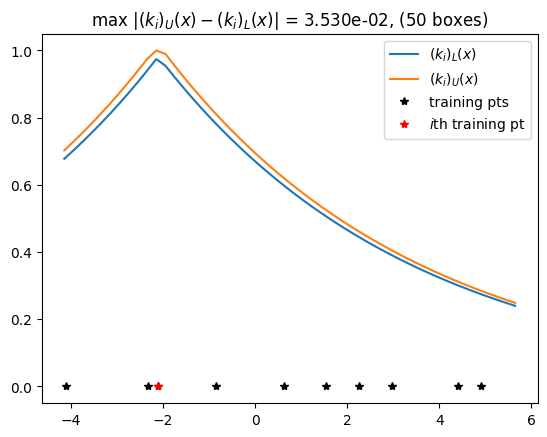

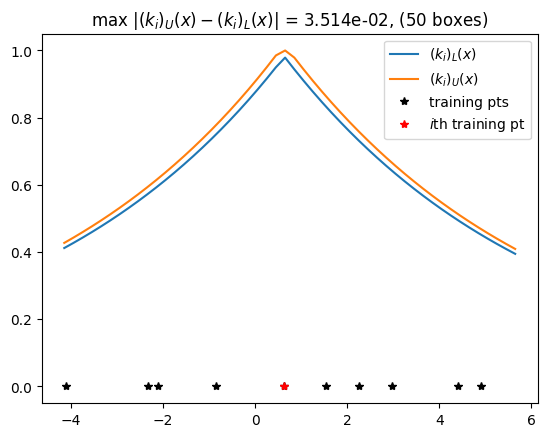

In [5]:
K_bandgaps = [np.linalg.norm(kUs[:,i] - kLs[:,i], np.inf) for i in range(n_samples)]

for i in range(n_samples):
    plt.plot(midpoints, kLs[:,i], label=r'$(k_i)_L(x)$')
    plt.plot(midpoints, kUs[:,i], label=r'$(k_i)_U(x)$')
    plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
    plt.plot(x_train[i,0], np.zeros(1), "r*", label=r'$i$th training pt')
    plt.legend()
    plt.title(r"max $|(k_i)_U(x) - (k_i)_L(x)|$ = {0:1.3e}, ({1:d} boxes)".format(K_bandgaps[i], nboxes))
    plt.show()

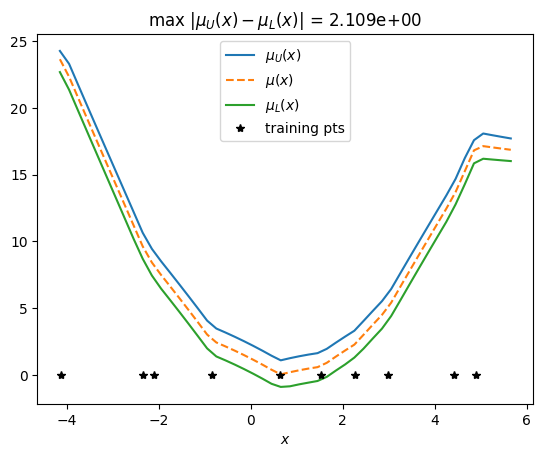

In [6]:
mu_bandgap = np.linalg.norm(muUs - muLs, np.inf)

plt.plot(midpoints, muUs, label=r'$\mu_U(x)$')
plt.plot(midpoints, mu, "--", label=r'$\mu(x)$')
plt.plot(midpoints, muLs, label=r'$\mu_L(x)$')
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.xlabel(r"$x$")
plt.legend()
plt.title(r"max $|\mu_U(x) - \mu_L(x)|$ = {0:1.3e}".format(mu_bandgap))
plt.show()

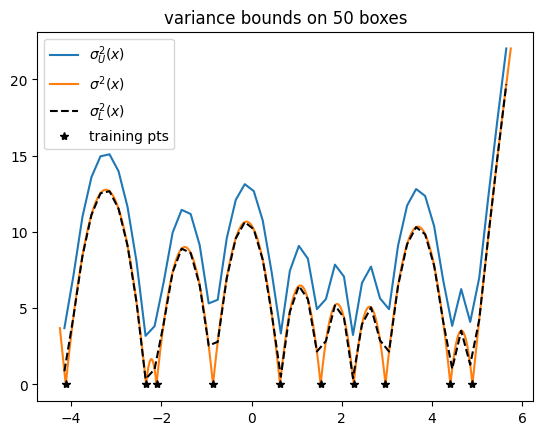

In [7]:
plt.plot(midpoints, s2Us, label=r"$\sigma^{2}_{U}(x)$")
plt.plot(X, sigmaX**2., label=r"$\sigma^{2}(x)$")
plt.plot(midpoints, s2Ls, "k--", label=r"$\sigma^{2}_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('variance bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

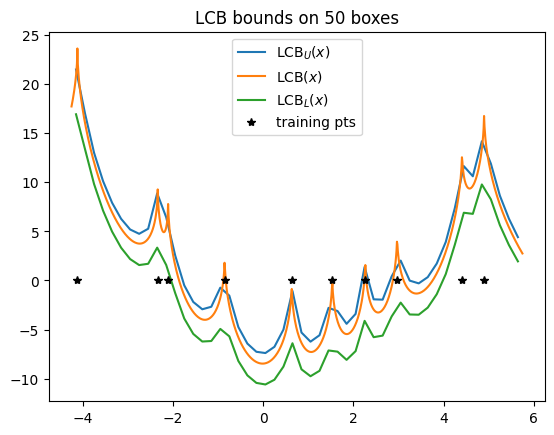

In [8]:
plt.plot(midpoints, LCB_Us, label=r"LCB$_{U}(x)$")
plt.plot(X, Y_acqf, label=r'LCB$(x)$')
plt.plot(midpoints, LCB_Ls, label=r"LCB$_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('LCB bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

In [9]:
from hiopbbpy.opt import BnBAlgorithm
bnb = BnBAlgorithm(acqf)
bnb.epsilon_diam = 1.e-12
bnb.epsilon_gap = 1.e-4
bnb.BnB_LBmethod = None
bnb.max_bnbiter = 2000
xstar = bnb.optimize()

=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -53.733827574631064
Initial acquisition upper bound: -5.049155709930046

--- BnB Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-53.733827574631064, U=-5.049155709930046
Current best feasible value (LUB): -5.049155709930046
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-35.558001910628775, U=-1.520407135763314
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-35.755401329980295, U=-1.0300438740852442
Queue size: 2 | LB=-35.755401329980295 | LUB=-5.049155709930046 | Gap<=30.706245620050247

--- BnB Iteration 2 ---
Node bounds: l=[0.75], u=[5.75]
Node acquisition bounds: L=-35.755401329980295, U=-1.0300438740852442
Current best feasible value (LUB): -5.049155709930046
  Branching to child: l=[0.75], u=[3.25]
  Child acquisition bounds: L=-27.153535609

  Child acquisition bounds: L=-7.295221155142553, U=-1.0386283068597777
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[3.875], u=[4.5]
  Child acquisition bounds: L=-1.9455330117690988, U=5.10619709448048
  Child pruned: L ≥ LUB + eps.
Queue size: 12 | LB=-10.689772721537379 | LUB=-8.470291346204625 | Gap<=2.2194813753327534

--- BnB Iteration 21 ---
Node bounds: l=[1.0625], u=[1.375]
Node acquisition bounds: L=-10.689772721537379, U=-6.837644726811927
Current best feasible value (LUB): -8.470291346204625
  Branching to child: l=[1.0625], u=[1.21875]
  Child acquisition bounds: L=-9.141473255916575, U=-7.180663663946045
  Branching to child: l=[1.21875], u=[1.375]
  Child acquisition bounds: L=-8.33349495778136, U=-6.228484894773323
  Child pruned: L ≥ LUB + eps.
Queue size: 12 | LB=-10.266740883658475 | LUB=-8.470291346204625 | Gap<=1.7964495374538494

--- BnB Iteration 22 ---
Node bounds: l=[-1.75], u=[-1.125]
Node acquisition bounds: L=-10.266740883658475, U=-3.750973403179

  Child acquisition bounds: L=-8.680895612082427, U=-8.4662078547533
Queue size: 17 | LB=-8.852728207206964 | LUB=-8.473434991941502 | Gap<=0.3792932152654611

--- BnB Iteration 42 ---
Node bounds: l=[0.046875], u=[0.0859375]
Node acquisition bounds: L=-8.852728207206964, U=-8.417532894713023
Current best feasible value (LUB): -8.473434991941502
  Branching to child: l=[0.046875], u=[0.06640625]
  Child acquisition bounds: L=-8.64857395211037, U=-8.430647922911474
  Branching to child: l=[0.06640625], u=[0.0859375]
  Child acquisition bounds: L=-8.62154272606005, U=-8.402618876539268
Queue size: 18 | LB=-8.847577783397602 | LUB=-8.473434991941502 | Gap<=0.37414279145609974

--- BnB Iteration 43 ---
Node bounds: l=[-0.109375], u=[-0.0703125]
Node acquisition bounds: L=-8.847577783397602, U=-8.420923384563444
Current best feasible value (LUB): -8.473434991941502
  Branching to child: l=[-0.109375], u=[-0.08984375]
  Child acquisition bounds: L=-8.620941197973615, U=-8.406922156943555
  B

  Child acquisition bounds: L=-8.52735975881495, U=-8.473354506204133
  Branching to child: l=[-0.00683594], u=[-0.00195312]
  Child acquisition bounds: L=-8.526917119632618, U=-8.472876334837352
Queue size: 29 | LB=-8.581092405446402 | LUB=-8.473434991941502 | Gap<=0.10765741350489932

--- BnB Iteration 64 ---
Node bounds: l=[-0.02148438], u=[-0.01171875]
Node acquisition bounds: L=-8.581092405446402, U=-8.473279507617455
Current best feasible value (LUB): -8.473434991941502
  Branching to child: l=[-0.02148438], u=[-0.01660156]
  Child acquisition bounds: L=-8.526983130344018, U=-8.473043823348299
  Branching to child: l=[-0.01660156], u=[-0.01171875]
  Child acquisition bounds: L=-8.527381374902735, U=-8.473409944125848
Queue size: 30 | LB=-8.579459751457438 | LUB=-8.473434991941502 | Gap<=0.10602475951593604

--- BnB Iteration 65 ---
Node bounds: l=[-0.00195312], u=[0.0078125]
Node acquisition bounds: L=-8.579459751457438, U=-8.47136372592934
Current best feasible value (LUB): -8.4

  Child acquisition bounds: L=-8.495163226798455, U=-8.44146806375258
Queue size: 38 | LB=-8.545881576888757 | LUB=-8.473434991941502 | Gap<=0.07244658494725442

--- BnB Iteration 79 ---
Node bounds: l=[0.10546875], u=[0.125]
Node acquisition bounds: L=-8.545881576888757, U=-8.324565487929753
Current best feasible value (LUB): -8.473434991941502
  Branching to child: l=[0.10546875], u=[0.11523438]
  Child acquisition bounds: L=-8.446672964092773, U=-8.335961298711489
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[0.11523438], u=[0.125]
  Child acquisition bounds: L=-8.423741012486026, U=-8.312692157897368
  Child pruned: L ≥ LUB + eps.
Queue size: 37 | LB=-8.545588082023157 | LUB=-8.473434991941502 | Gap<=0.07215309008165427

--- BnB Iteration 80 ---
Node bounds: l=[0.046875], u=[0.05664062]
Node acquisition bounds: L=-8.545588082023157, U=-8.43653648039253
Current best feasible value (LUB): -8.473434991941502
  Branching to child: l=[0.046875], u=[0.05175781]
  Child acquisit

...

  Child acquisition bounds: L=-8.473491008884038, U=-8.473396322557367
Queue size: 806 | LB=-8.473572096054816 | LUB=-8.473438626207447 | Gap<=0.00013346984736983813

--- BnB Iteration 1309 ---
Node bounds: l=[-0.01015472], u=[-0.01013565]
Node acquisition bounds: L=-8.473572096054816, U=-8.473395215063206
Current best feasible value (LUB): -8.473438626207447
  Branching to child: l=[-0.01015472], u=[-0.01014519]
  Child acquisition bounds: L=-8.473490430154161, U=-8.473395401862962
  Branching to child: l=[-0.01014519], u=[-0.01013565]
  Child acquisition bounds: L=-8.473490056902488, U=-8.473395027860523
Queue size: 807 | LB=-8.473571710098664 | LUB=-8.473438626207447 | Gap<=0.000133083891217467

--- BnB Iteration 1310 ---
Node bounds: l=[-0.01457977], u=[-0.0145607]
Node acquisition bounds: L=-8.473571710098664, U=-8.473395395297215
Current best feasible value (LUB): -8.473438626207447
  Branching to child: l=[-0.01457977], u=[-0.01457024]
  Child acquisition bounds: L=-8.4734898928

  Child acquisition bounds: L=-8.473482892527135, U=-8.47338822127864
  Branching to child: l=[-0.0147419], u=[-0.01473236]
  Child acquisition bounds: L=-8.473483295096681, U=-8.473388623130203
Queue size: 821 | LB=-8.473564479126333 | LUB=-8.473438626207447 | Gap<=0.00012585291888633776

--- BnB Iteration 1334 ---
Node bounds: l=[-0.01728821], u=[-0.01725006]
Node acquisition bounds: L=-8.473564479126333, U=-8.473225511607911
Current best feasible value (LUB): -8.473438626207447
  Branching to child: l=[-0.01728821], u=[-0.01726913]
  Child acquisition bounds: L=-8.47340065936895, U=-8.473224683238957
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[-0.01726913], u=[-0.01725006]
  Child acquisition bounds: L=-8.473402316881494, U=-8.473226338371497
  Child pruned: L ≥ LUB + eps.
Queue size: 820 | LB=-8.473564343112045 | LUB=-8.473438626207447 | Gap<=0.00012571690459850515

--- BnB Iteration 1335 ---
Node bounds: l=[-0.00744629], u=[-0.00740814]
Node acquisition bounds: L=-8.47

  Child acquisition bounds: L=-8.473394497754033, U=-8.473217256324574
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[-0.00735092], u=[-0.00733185]
  Child acquisition bounds: L=-8.4733928069564, U=-8.473215563052785
  Child pruned: L ≥ LUB + eps.
Queue size: 829 | LB=-8.47355763182737 | LUB=-8.473438626207447 | Gap<=0.00011900561992383984

--- BnB Iteration 1358 ---
Node bounds: l=[-0.0098114], u=[-0.00979233]
Node acquisition bounds: L=-8.47355763182737, U=-8.473380706481898
Current best feasible value (LUB): -8.473438626207447
  Branching to child: l=[-0.0098114], u=[-0.00980186]
  Child acquisition bounds: L=-8.473475977621025, U=-8.473380922296274
  Branching to child: l=[-0.00980186], u=[-0.00979233]
  Child acquisition bounds: L=-8.473475546340305, U=-8.473380490264493
Queue size: 830 | LB=-8.473557200449246 | LUB=-8.473438626207447 | Gap<=0.00011857424179950726

--- BnB Iteration 1359 ---
Node bounds: l=[-0.0149231], u=[-0.01490402]
Node acquisition bounds: L=-8.473557

  Child acquisition bounds: L=-8.47346979298874, U=-8.473374727147723
  Branching to child: l=[-0.00966835], u=[-0.00965881]
  Child acquisition bounds: L=-8.473469339138124, U=-8.473374272545849
Queue size: 840 | LB=-8.47355099836375 | LUB=-8.473438626207447 | Gap<=0.00011237215630366393

--- BnB Iteration 1377 ---
Node bounds: l=[-0.0174408], u=[-0.01740265]
Node acquisition bounds: L=-8.47355099836375, U=-8.47321206506576
Current best feasible value (LUB): -8.473438626207447
  Branching to child: l=[-0.0174408], u=[-0.01742172]
  Child acquisition bounds: L=-8.473387168104331, U=-8.473211211011986
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[-0.01742172], u=[-0.01740265]
  Child acquisition bounds: L=-8.473388876986066, U=-8.473212917514283
  Child pruned: L ≥ LUB + eps.
Queue size: 839 | LB=-8.473550995192262 | LUB=-8.473438626207447 | Gap<=0.00011236898481570279

--- BnB Iteration 1378 ---
Node bounds: l=[-0.01505661], u=[-0.01503754]
Node acquisition bounds: L=-8.47355

  Child acquisition bounds: L=-8.473465003159712, U=-8.473370361337844
Queue size: 847 | LB=-8.473545886137323 | LUB=-8.473438626207447 | Gap<=0.00010725992987659083

--- BnB Iteration 1392 ---
Node bounds: l=[-0.00956345], u=[-0.00954437]
Node acquisition bounds: L=-8.473545886137323, U=-8.473368928743938
Current best feasible value (LUB): -8.473438626207447
  Branching to child: l=[-0.00956345], u=[-0.00955391]
  Child acquisition bounds: L=-8.473464240373314, U=-8.473369165516933
  Branching to child: l=[-0.00955391], u=[-0.00954437]
  Child acquisition bounds: L=-8.473463767175673, U=-8.473368691567865
Queue size: 848 | LB=-8.473545425662081 | LUB=-8.473438626207447 | Gap<=0.00010679945463465401

--- BnB Iteration 1393 ---
Node bounds: l=[-0.01517105], u=[-0.01515198]
Node acquisition bounds: L=-8.473545425662081, U=-8.47336918491801
Current best feasible value (LUB): -8.473438626207447
  Branching to child: l=[-0.01517105], u=[-0.01516151]
  Child acquisition bounds: L=-8.47346358

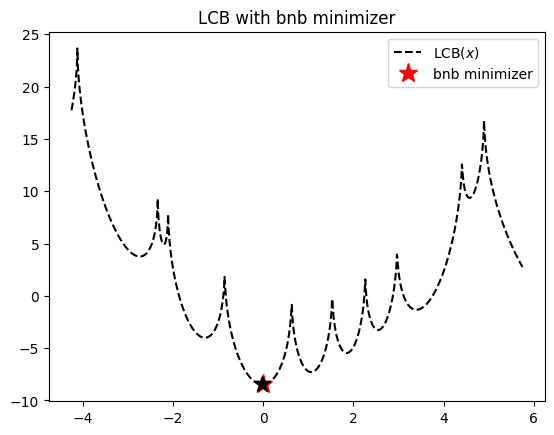

In [10]:
y_star = acqf.evaluate(xstar)
xstar_true = np.atleast_2d(X[np.argmin(Y_acqf)])
ystar_true = acqf.evaluate(xstar_true)
#print(xstar_true)
plt.plot(X, Y_acqf, 'k--', label=r'LCB$(x)$')
plt.plot(xstar, y_star, "r*", markersize=14, label=r'bnb minimizer')
plt.plot(xstar_true, ystar_true, "k*", markersize=12)
#for i in range(2):
#    plt.plot(xstar_bounds.flatten()[i], y_star[0,0] , "k*")
plt.title('LCB with bnb minimizer'.format(nboxes))
plt.legend()
plt.show()


In [11]:
bo_maxiter = 3
batch_size = 1
options = {
    'acquisition_type': 'LCB',
    'acquisition_method' : 'bnb',
    'bo_maxiter': bo_maxiter, 
    'batch_size': batch_size,
    'opt_solver': "SLSQP"    
}

In [12]:
from hiopbbpy.opt import BOAlgorithm
bo = BOAlgorithm(problem, gp_model, x_train, y_train, options=options)
bo.optimize()

hiopbbpy Problem name: QuadraticShift
hiopbbpy Max BO iter: 3
hiopbbpy Optimizing acquisition (LCB) with 10 random initial points
hiopbbpy Batch type: KB
hiopbbpy Batch size: 1
hiopbbpy Internal optimization solver: SLSQP
hiopbbpy Internal optimization solver options: {'maxiter': 200}
hiopbbpy Initial training set: 10 samples, 1 dimensions
hiopbbpy Logger level: INFO
hiopbbpy Best UNCONSTRAINED objective from 10 initial samples: 1.3949e-02 
hiopbbpy Best CONSTRAINED objective from 10 feasible initial samples: 1.3949e-02
hiopbbpy *****************************
hiopbbpy Iteration 1/3
hiopbbpy In batch 1/1
hiopbbpy Start finding the best sampling point:


=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -53.73382757516653
Initial acquisition upper bound: -5.049155709912285

--- BnB Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-53.73382757516653, U=-5.049155709912285
Current best feasible value (LUB): -5.049155709912285
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-35.558001910866395, U=-1.5204071357362672
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-35.755401330219655, U=-1.0300438740592366
Queue size: 2 | LB=-35.755401330219655 | LUB=-5.049155709912285 | Gap<=30.70624562030737

--- BnB Iteration 2 ---
Node bounds: l=[0.75], u=[5.75]
Node acquisition bounds: L=-35.755401330219655, U=-1.0300438740592366
Current best feasible value (LUB): -5.049155709912285
  Branching to child: l=[0.75], u=[3.25]
  Child acquisition bounds: L=-27.15353560991

  Child acquisition bounds: L=-9.610755655552083, U=-7.915263814172302
Queue size: 13 | LB=-10.724910998708333 | LUB=-8.47029134617631 | Gap<=2.254619652532023

--- BnB Iteration 19 ---
Node bounds: l=[0.75], u=[1.0625]
Node acquisition bounds: L=-10.724910998708333, U=-6.800657198532339
Current best feasible value (LUB): -8.47029134617631
  Branching to child: l=[0.75], u=[0.90625]
  Child acquisition bounds: L=-8.321444018393795, U=-6.136139152944924
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[0.90625], u=[1.0625]
  Child acquisition bounds: L=-9.148051482096436, U=-7.1681158591696645
Queue size: 13 | LB=-10.713043303086533 | LUB=-8.47029134617631 | Gap<=2.2427519569102223

--- BnB Iteration 20 ---
Node bounds: l=[3.25], u=[4.5]
Node acquisition bounds: L=-10.713043303086533, U=0.9570309714396359
Current best feasible value (LUB): -8.47029134617631
  Branching to child: l=[3.25], u=[3.875]
  Child acquisition bounds: L=-7.295221155139534, U=-1.038628306828084
  Child prun

  Child acquisition bounds: L=-8.261193616039241, U=-7.26329960341183
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[1.140625], u=[1.21875]
  Child acquisition bounds: L=-8.052418015706214, U=-7.039729853466147
  Child pruned: L ≥ LUB + eps.
Queue size: 14 | LB=-9.073412227569259 | LUB=-8.473434991913262 | Gap<=0.5999772356559969

--- BnB Iteration 36 ---
Node bounds: l=[0.125], u=[0.203125]
Node acquisition bounds: L=-9.073412227569259, U=-8.183757815662087
Current best feasible value (LUB): -8.473434991913262
  Branching to child: l=[0.125], u=[0.1640625]
  Child acquisition bounds: L=-8.691218715997355, U=-8.24604250286492
  Branching to child: l=[0.1640625], u=[0.203125]
  Child acquisition bounds: L=-8.565208954652736, U=-8.113212850496737
Queue size: 15 | LB=-8.996868325903657 | LUB=-8.473434991913262 | Gap<=0.5234333339903952

--- BnB Iteration 37 ---
Node bounds: l=[0.28125], u=[0.4375]
Node acquisition bounds: L=-8.996868325903657, U=-7.0380382424800905
Current best f

  Child acquisition bounds: L=-8.534546486422055, U=-8.427307588858424
  Branching to child: l=[-0.08007812], u=[-0.0703125]
  Child acquisition bounds: L=-8.546124074726439, U=-8.438841857717266
Queue size: 27 | LB=-8.621542726033148 | LUB=-8.473434991913262 | Gap<=0.1481077341198862

--- BnB Iteration 58 ---
Node bounds: l=[0.06640625], u=[0.0859375]
Node acquisition bounds: L=-8.621542726033148, U=-8.402618876511497
Current best feasible value (LUB): -8.473434991913262
  Branching to child: l=[0.06640625], u=[0.07617188]
  Child acquisition bounds: L=-8.519841029795218, U=-8.410301933676669
  Branching to child: l=[0.07617188], u=[0.0859375]
  Child acquisition bounds: L=-8.504288125711076, U=-8.394481268255817
Queue size: 28 | LB=-8.620941197946076 | LUB=-8.473434991913262 | Gap<=0.14750620603281384

--- BnB Iteration 59 ---
Node bounds: l=[-0.109375], u=[-0.08984375]
Node acquisition bounds: L=-8.620941197946076, U=-8.406922156915112
Current best feasible value (LUB): -8.473434991

...

  Child acquisition bounds: L=-5.644921131226188, U=-4.463495840769149
Queue size: 28 | LB=-6.724281935447127 | LUB=-5.467242539723192 | Gap<=1.2570393957239352

--- BnB Iteration 35 ---
Node bounds: l=[2.], u=[2.3125]
Node acquisition bounds: L=-6.724281935447127, U=-2.3173354792135514
Current best feasible value (LUB): -5.467242539723192
  Branching to child: l=[2.], u=[2.15625]
  Child acquisition bounds: L=-5.636949282999486, U=-3.4850319942246113
  Branching to child: l=[2.15625], u=[2.3125]
  Child acquisition bounds: L=-3.281545861851611, U=-0.21828412655894747
  Child pruned: L ≥ LUB + eps.
Queue size: 28 | LB=-6.699483957587109 | LUB=-5.467242539723192 | Gap<=1.232241417863917

--- BnB Iteration 36 ---
Node bounds: l=[1.375], u=[1.6875]
Node acquisition bounds: L=-6.699483957587109, U=0.10193388001615178
Current best feasible value (LUB): -5.467242539723192
  Branching to child: l=[1.375], u=[1.53125]
  Child acquisition bounds: L=-5.770314828694082, U=-3.1682138526355583
  Br

  Child acquisition bounds: L=-5.636168157730687, U=-5.356529739883759
Queue size: 32 | LB=-5.9101073361090535 | LUB=-5.467646709393624 | Gap<=0.4424606267154294

--- BnB Iteration 56 ---
Node bounds: l=[-0.5], u=[-0.421875]
Node acquisition bounds: L=-5.9101073361090535, U=-4.922360458811503
Current best feasible value (LUB): -5.467646709393624
  Branching to child: l=[-0.5], u=[-0.4609375]
  Child acquisition bounds: L=-5.350038805646063, U=-4.848888620661129
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[-0.4609375], u=[-0.421875]
  Child acquisition bounds: L=-5.480985656406726, U=-4.9816578904810065
Queue size: 32 | LB=-5.900830458927248 | LUB=-5.467646709393624 | Gap<=0.43318374953362415

--- BnB Iteration 57 ---
Node bounds: l=[0.2421875], u=[0.28125]
Node acquisition bounds: L=-5.900830458927248, U=-5.353420244006625
Current best feasible value (LUB): -5.467646709393624
  Branching to child: l=[0.2421875], u=[0.26171875]
  Child acquisition bounds: L=-5.59267298954015,

  Child acquisition bounds: L=-4.138295950297176, U=-2.970209570576907
  Child pruned: L ≥ LUB + eps.
Queue size: 26 | LB=-5.636168157730687 | LUB=-5.468107369242738 | Gap<=0.16806078848794836

--- BnB Iteration 79 ---
Node bounds: l=[0.37890625], u=[0.3984375]
Node acquisition bounds: L=-5.636168157730687, U=-5.356529739883759
Current best feasible value (LUB): -5.468107369242738
  Branching to child: l=[0.37890625], u=[0.38867188]
  Child acquisition bounds: L=-5.513585423175831, U=-5.37344235121266
  Branching to child: l=[0.38867188], u=[0.3984375]
  Child acquisition bounds: L=-5.479039028312849, U=-5.338167424205807
Queue size: 27 | LB=-5.605893843474146 | LUB=-5.468107369242738 | Gap<=0.13778647423140722

--- BnB Iteration 80 ---
Node bounds: l=[0.3203125], u=[0.33007812]
Node acquisition bounds: L=-5.605893843474146, U=-5.468107369242738
Current best feasible value (LUB): -5.468107369242738
Skip: Node diameter 0.009765625 <= 0.01

--- BnB Iteration 81 ---
Node bounds: l=[0.3300

hiopbbpy   (mu, sigma) at new sample x: 0.2999941749368453, 1.922700514726528 
hiopbbpy Best objective found in this iteration: 1.8046e-01 
hiopbbpy Training set size is now 13
hiopbbpy Current best objective: 9.7656e-02 (previous best: 9.7656e-02)
hiopbbpy Objective function improvement: 0.0000e+00
hiopbbpy ===================================
hiopbbpy Bayesian Optimization completed
hiopbbpy Total evaluations for initial samples: 10
hiopbbpy Total evaluations for BO iterations: 3
hiopbbpy Optimal at BO iteration: 2 
hiopbbpy Best value: 0.09765625
hiopbbpy ===================================


  Child acquisition bounds: L=-4.870246749901736, U=-4.341467232387353
  Child pruned: L ≥ LUB + eps.
Queue size: 4 | LB=-5.480985656406726 | LUB=-5.468107369242738 | Gap<=0.012878287163987423

--- BnB Iteration 104 ---
Node bounds: l=[-0.4609375], u=[-0.421875]
Node acquisition bounds: L=-5.480985656406726, U=-4.9816578904810065
Current best feasible value (LUB): -5.468107369242738
  Branching to child: l=[-0.4609375], u=[-0.44140625]
  Child acquisition bounds: L=-5.205135937787377, U=-4.953773378584395
  Child pruned: L ≥ LUB + eps.
  Branching to child: l=[-0.44140625], u=[-0.421875]
  Child acquisition bounds: L=-5.257257082796292, U=-5.0060218798556075
  Child pruned: L ≥ LUB + eps.
Queue size: 3 | LB=-5.479039028312849 | LUB=-5.468107369242738 | Gap<=0.010931659070110733

--- BnB Iteration 105 ---
Node bounds: l=[0.38867188], u=[0.3984375]
Node acquisition bounds: L=-5.479039028312849, U=-5.338167424205807
Current best feasible value (LUB): -5.468107369242738
Skip: Node diameter

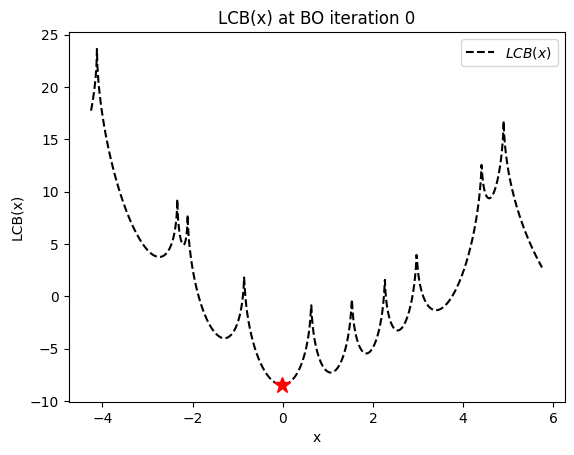

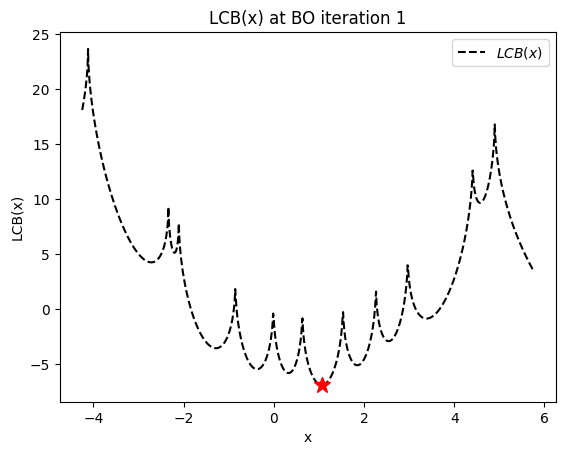

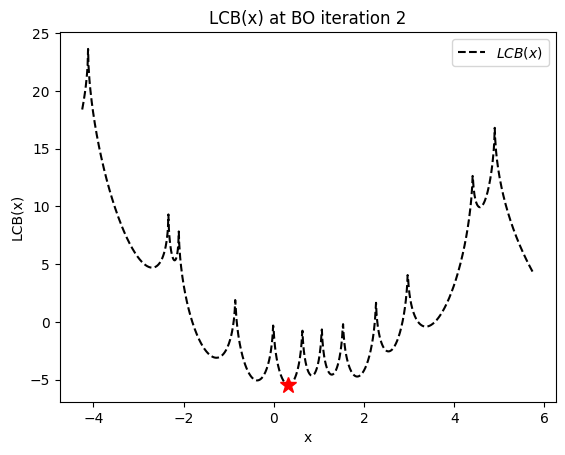

In [13]:
x_bo = bo.getOptimizationHistory()[0]
x_train_superset = np.concatenate((x_train, x_bo), axis=0)
for i in range(bo_maxiter):
    x_train2 = x_train_superset[:-bo_maxiter+i]
    y_train2 = problem.evaluate(x_train2)
    gp_model2 = smtKRG(theta, problem.xlimits, nx)
    gp_model2.train(x_train2, y_train2)
    acqf2 = LCBacquisition(gp_model2, beta=beta)
    Y_acqf2 = acqf2.evaluate(X)
    y_star2 = acqf2.evaluate(np.atleast_2d(x_bo[i]))
    plt.plot(X, Y_acqf2,'k--', label=r'$LCB(x)$')
    plt.plot(x_bo[i], y_star2, r'r*', markersize=12)
    #plt.plot(X, muX, "-.", label=r'$\mu(x)$')
    #plt.plot(X, sigmaX, label=r'$\sigma(x)$')
    plt.xlabel("x")
    plt.ylabel("LCB(x)")
    plt.legend()
    plt.title(r"LCB(x) at BO iteration {0:d}".format(i))
    plt.show()
    
    